In [1]:
import torch
from torch import nn
from d2l import torch as d2l
import os

In [2]:
class AttentionDecoder(d2l.Decoder):
    def __init__(self, **kwargs):
        super(AttentionDecoder, self).__init__(**kwargs)

    @property
    def attention_weights(self):
        raise NotImplementedError

In [5]:
class Seq2SeqAttentionDecoder(AttentionDecoder):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers, dropout=0, **kwargs):
        super(Seq2SeqAttentionDecoder, self).__init__(**kwargs)
        self.attention = d2l.AdditiveAttention(num_hiddens, dropout)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size + num_hiddens, num_hiddens, num_layers, dropout=dropout)
        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        outputs, hidden_state = enc_outputs
        return (outputs.permute(1, 0, 2), hidden_state, enc_valid_lens)
    
    def forward(self, X, state):
        enc_outputs, hidden_state, enc_valid_lens = state
        X = self.embedding(X).permute(1, 0, 2)
        outputs, self._attention_weights = [], []

        for x in X:
            query = hidden_state[-1].unsqueeze(1)
            context = self.attention(query, enc_outputs, enc_outputs, enc_valid_lens)
            x = torch.cat((context, x.unsqueeze(1)), dim=-1)
            out, hidden_state = self.rnn(x.permute(1, 0, 2), hidden_state)
            outputs.append(out)
            self._attention_weights.append(self.attention.attention_weights)

        outputs = self.dense(torch.cat(outputs, dim=0))
        ret = outputs.permute(1, 0, 2), (enc_outputs, hidden_state, enc_valid_lens)
        return ret
    
    @property
    def attention_weights(self):
        return self._attention_weights

In [6]:
encoder = d2l.Seq2SeqEncoder(vocab_size = 10, embed_size=8, num_hiddens=16, num_layers=2)  
encoder.eval()
decoder = Seq2SeqAttentionDecoder(vocab_size=10, embed_size=8, num_hiddens=16, num_layers=2)  
decoder.eval()

X = torch.zeros((4,7), dtype=torch.long)
state = decoder.init_state(encoder(X), None)
output, state = decoder(X, state)
output.shape, len(state), state[0].shape, len(state[1]), state[1][0].shape

(torch.Size([4, 7, 10]), 3, torch.Size([4, 7, 16]), 2, torch.Size([4, 16]))

In [7]:
def read_data_nmt():
    '''
    load dataset
    '''
    data_dir = d2l.download_extract('fra-eng')

    with open(os.path.join(data_dir, 'fra.txt'), 'r', encoding='utf-8') as f:
        return f.read()

In [8]:
def preprocess_nmt(text):
    '''
    process dataset
    '''
    def no_space(char, prev_char):
        return char in set(',.!?') and prev_char != ' '
    
    text = text.replace('\u202f', ' ').replace('\xa0', ' ').lower()
    out = [
        ' ' + char if i > 0 and no_space(char, text[i-1]) else char
        for i, char in enumerate(text)
    ]

    return ''.join(out)

In [9]:
def tokenize_nmt(text, num_examples=None):
    '''
    tokenize dataset
    '''
    source, target = [], []
    for i, line in enumerate(text.split('\n')):
        if num_examples and i > num_examples:
            break

        parts = line.split('\t')
        if len(parts) == 2:
            source.append(parts[0].split(' '))
            target.append(parts[1].split(' '))

    return source, target

In [10]:
def truncate_pad(line, num_steps, padding_token):
    '''
    truncate or pad text sequences
    '''
    if len(line) > num_steps:
        return line[:num_steps]
    
    return line + [padding_token] * (num_steps - len(line))

In [11]:
def build_array_nmt(lines, vocab, num_steps):
    '''
    turn to small batch
    '''
    lines = [vocab[l] for l in lines]
    lines = [l + [vocab['<eos>']] for l in lines]
    array = torch.tensor([truncate_pad(l, num_steps, vocab['<pad>']) for l in lines])
    valid_len = (array != vocab['<pad>']).type(torch.int32).sum(1)

    return array, valid_len

In [12]:
def load_data_nmt(batch_size, num_steps, num_examples=600):
    text = preprocess_nmt(read_data_nmt())
    source, target = tokenize_nmt(text, num_examples)

    src_vocab = d2l.Vocab(source, min_freq=2, 
                          reserved_tokens=['<pad>','<bos>','<eos>'])
    tgt_vocab = d2l.Vocab(target, min_freq=2, 
                          reserved_tokens=['<pad>','<bos>','<eos>'])
    
    src_array, src_valid_len = build_array_nmt(source, src_vocab, num_steps)
    tgt_array, tgt_valid_len = build_array_nmt(target, tgt_vocab, num_steps)

    data_arrays = (src_array, src_valid_len, tgt_array, tgt_valid_len)
    data_iter = d2l.load_array(data_arrays, batch_size)

    return data_iter, src_vocab, tgt_vocab

In [13]:
class EncoderDecoderWithState(d2l.EncoderDecoder):
    def forward(self, enc_X, dec_X, enc_valid_len, *args):
        enc_outputs = self.encoder(enc_X, enc_valid_len)
        dec_state = self.decoder.init_state(enc_outputs, enc_valid_len)
        return self.decoder(dec_X, dec_state)

loss 0.020, 3245.0 tokens/sec on cpu


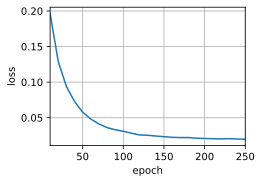

In [14]:
embed_size, num_hiddens, num_layers, dropout = 32, 32, 2, 0.1
batch_size, num_steps = 64, 10
lr, num_epochs, device = 0.005, 250, torch.device('cpu')

train_iter, src_vocab, tgt_vocab = load_data_nmt(batch_size, num_steps)
encoder = d2l.Seq2SeqEncoder(len(src_vocab), embed_size, num_hiddens, num_layers, dropout)
decoder = Seq2SeqAttentionDecoder(len(tgt_vocab), embed_size, num_hiddens, num_layers, dropout)
net = EncoderDecoderWithState(encoder, decoder)
d2l.train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)

In [15]:
engs = ['go', "i lost .", 'he\'s calm .', 'i\'m home .'] 
fras = ['va !', 'j\' ai perdu .', 'il est calme .', 'je suis chez moi .']

for eng, fra in zip(engs, fras):
    translation, dec_attention_weight_seq = d2l.predict_seq2seq(net, eng, src_vocab,
                                                               tgt_vocab, num_steps, device, True)   
    print(f' {eng} => {translation}, ',
         f'bleu {d2l.bleu(translation, fra, k=2):.3f}')

 go => dégage !,  bleu 0.000
 i lost . => j'ai perdu .,  bleu 0.492
 he's calm . => il est bon .,  bleu 0.658
 i'm home . => je suis chez moi .,  bleu 1.000


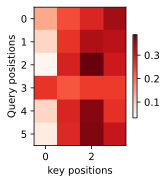

In [17]:
translation, dec_attention_weight_seq = d2l.predict_seq2seq(
    net, engs[-1], src_vocab, tgt_vocab, num_steps, device, True
)

attention_weights = torch.cat(
    [step[0][0][0] for step in dec_attention_weight_seq],
    dim=0
).reshape((1, 1, -1, num_steps))

d2l.show_heatmaps(attention_weights[:,:,:,:len(engs[-1].split()) + 1].cpu(),
                 xlabel = 'key positions', ylabel = 'Query posistions')